In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [20]:
path = r"C:\Users\Nailo\Downloads\archive\plantvillage dataset\color" # Change this path to your Plant Village folder directory
print("Path to dataset files:", path)                                 # The images I am using are the color images only

Path to dataset files: C:\Users\Nailo\Downloads\archive\plantvillage dataset\color


In [21]:
data = tf.keras.preprocessing.image_dataset_from_directory(path, image_size=(224, 224), batch_size=32)
for images, labels in data.take(1):
    print(images.shape)
    print(labels.shape)

Found 54305 files belonging to 38 classes.
(32, 224, 224, 3)
(32,)


In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(path, validation_split=0.2, subset='training', seed=42, image_size=(224, 224), batch_size=32)
val_ds = tf.keras.utils.image_dataset_from_directory(path, validation_split=0.2, subset='validation', seed=42, image_size=(224, 224), batch_size=32)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [102]:
def img_plt(images, labels):
    plt.figure(figsize=(15, 8))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Class: " + str(labels[i].numpy()))
        plt.axis("on")
    plt.show()

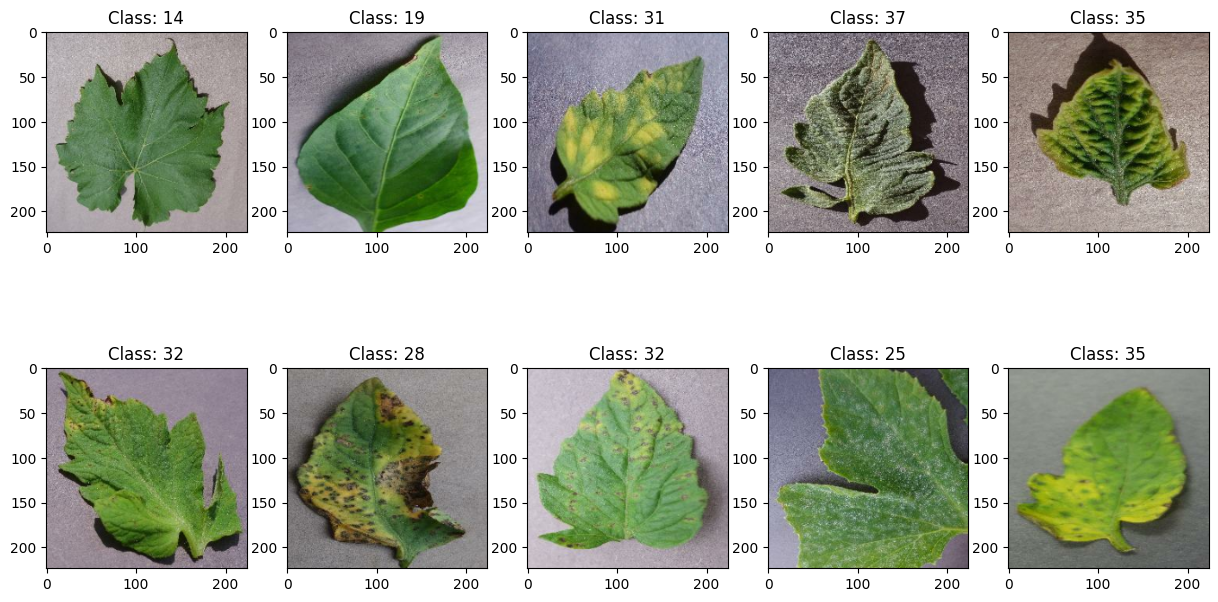

In [103]:
for images, labels in train_ds.take(1):
    img_plt(images, labels)

In [76]:
class_names = train_ds.class_names
num_classes = len(class_names)

In [77]:
samples = {}
needed = num_classes  # should be 38

for images, labels in train_ds:
    for i in range(len(labels)):
        label = labels[i].numpy()
        
        if label not in samples:
            samples[label] = images[i]
            
        if len(samples) == needed:
            break
    if len(samples) == needed:
        break

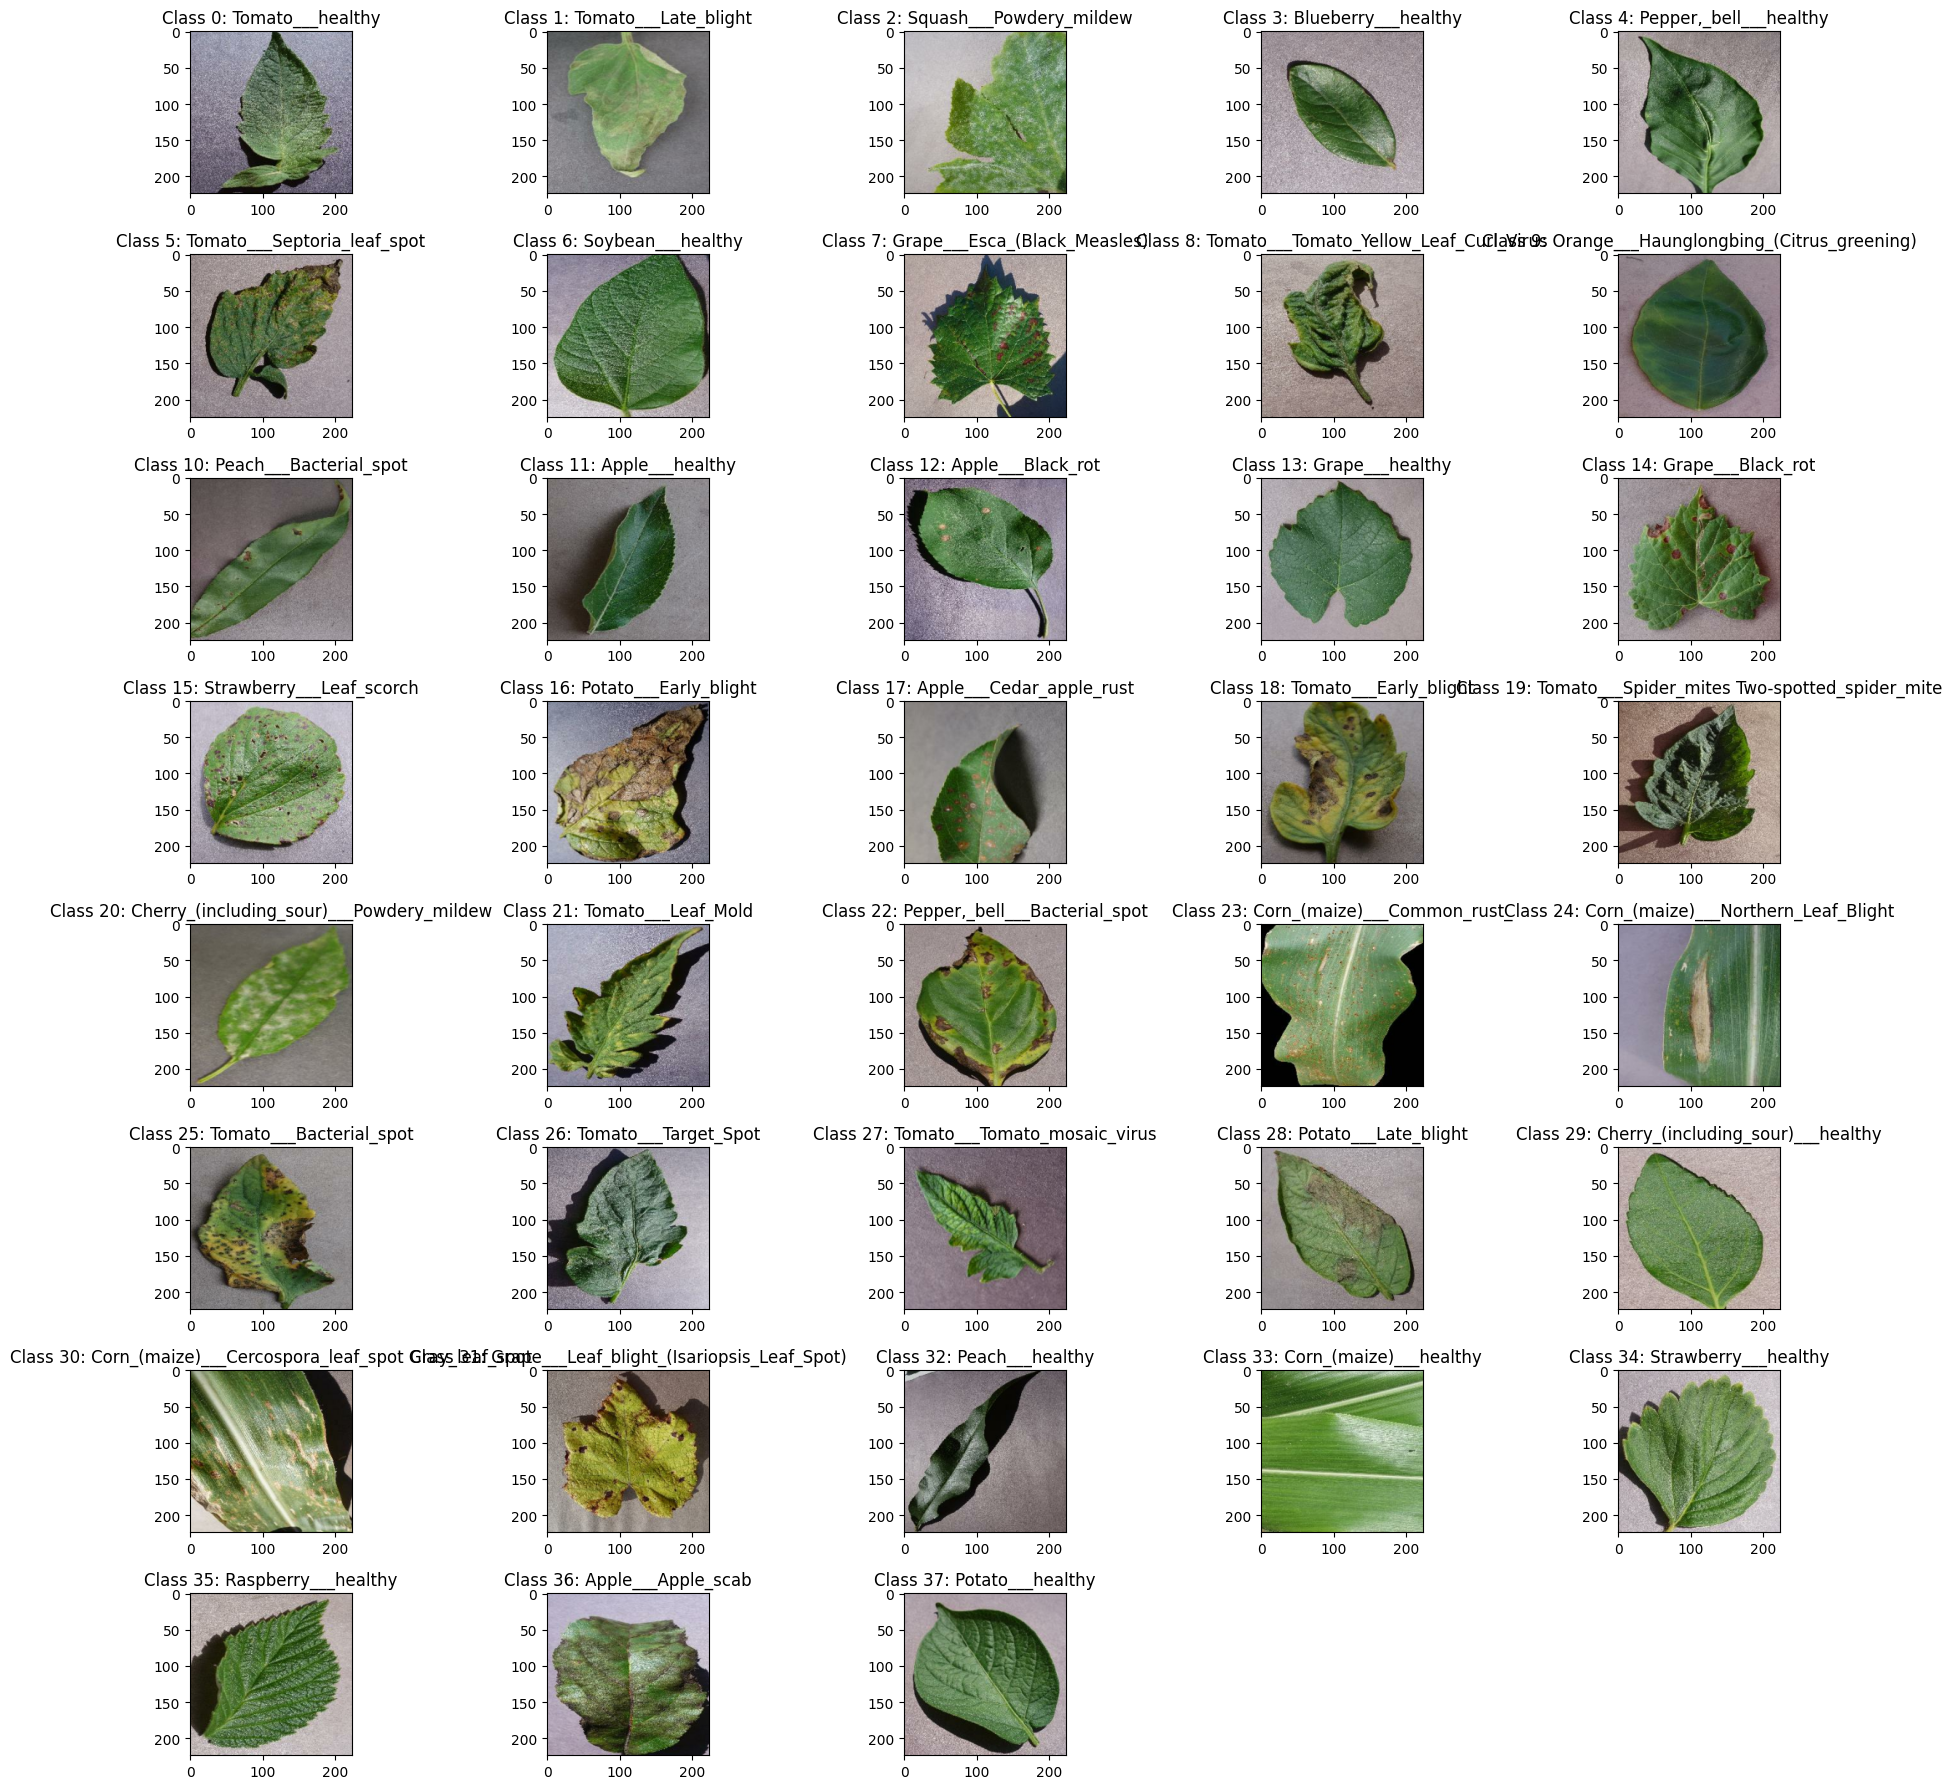

In [105]:
plt.figure(figsize=(18, 18))

for i, (label, image) in enumerate(samples.items()):
    plt.subplot(8, 5, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Class {i}: {class_names[label]}")
    plt.axis("on")

plt.tight_layout()
plt.show()